# Phase 6: Baseline Modeling - Dubai Apartment Price Prediction

## Objectives
- Load the cleaned dataset `ready_cleaned_v2.csv`
- Build a preprocessing pipeline to handle categorical and numerical features
- Establish a baseline performance using Linear Regression
- Evaluate non-linear relationships using Random Forest Regressor
- Compare models using MAE, RMSE, and R² scores (evaluated on the original AED price scale)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('ggplot')
print('Imports successful!')

Imports successful!


### Load clean dataset

In [2]:
df = pd.read_csv('data/ready_cleaned_v2.csv')
print('Dataset dimensions:', df.shape)
df[['price', 'beds', 'baths', 'area', 'luxury_score', 'has_view', 'has_maids_room', 'is_freehold', 'dist_to_burj', 'dist_to_airport', 'dist_to_beach']].head()

Dataset dimensions: (16105, 102)


,price,beds,baths,area,luxury_score,has_view,has_maids_room,is_freehold,dist_to_burj,dist_to_airport,dist_to_beach
0,1000000.0,1,2,999.0,2,0,0,0,17.011064,27.027253,11.680072
1,880000.0,1,2,686.0,0,0,0,0,17.011064,27.027253,11.680072
2,1030000.0,1,2,893.0,3,0,1,1,17.011064,27.027253,11.680072
3,1850000.0,2,1,765.0,0,0,0,0,11.008688,19.763160,8.528915
4,900000.0,1,2,647.0,2,0,0,0,17.011064,27.027253,11.680072


### Prepare Features and Target Variable

In [3]:
num_features = ['beds', 'baths', 'area', 'luxury_score', 'has_view', 'has_maids_room', 'is_freehold', 'dist_to_burj', 'dist_to_airport', 'dist_to_beach']
cat_features = ['furnished']
target = 'log_price'

X = df[num_features + ['district'] + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training features shape:', X_train.shape)
print('Testing features shape:', X_test.shape)

Training features shape: (12884, 12)
Testing features shape: (3221, 12)


### Preprocessing Pipeline

In [4]:
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import KFold

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('district_te', TargetEncoder(smooth='auto', cv=KFold(n_splits=5, shuffle=True, random_state=42)), ['district']),
    ('cat', cat_transformer, cat_features)
])
print('Pipeline configured successfully!')

Pipeline configured successfully!


### Compare Models on Original Price Scale

In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    
    # Predict log_price and convert back to original scale (AED)
    preds_log = pipeline.predict(X_test)
    preds = np.expm1(preds_log)
    y_test_orig = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_orig, preds)
    rmse = np.sqrt(mean_squared_error(y_test_orig, preds))
    r2 = r2_score(y_test_orig, preds)
    
    results.append({
        'Model': name,
        'MAE (AED)': mae,
        'RMSE (AED)': rmse,
        'R2 Score': r2
    })
    print(f'{name:20} -> MAE: {mae:,.2f} AED, RMSE: {rmse:,.2f} AED, R2: {r2:.4f}')

results_df = pd.DataFrame(results)
results_df

Linear Regression    -> MAE: 874,456.35 AED, RMSE: 1,440,535.08 AED, R2: 0.4690


Random Forest        -> MAE: 823,373.45 AED, RMSE: 1,346,537.31 AED, R2: 0.5360


,Model,MAE (AED),RMSE (AED),R2 Score
0,Linear Regression,874456.345721,1.440535e+06,0.468961
1,Random Forest,823373.450496,1.346537e+06,0.536003


### Feature Importance Analysis

C:\Users\adith\AppData\Local\Temp\ipykernel_14188\3654267409.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


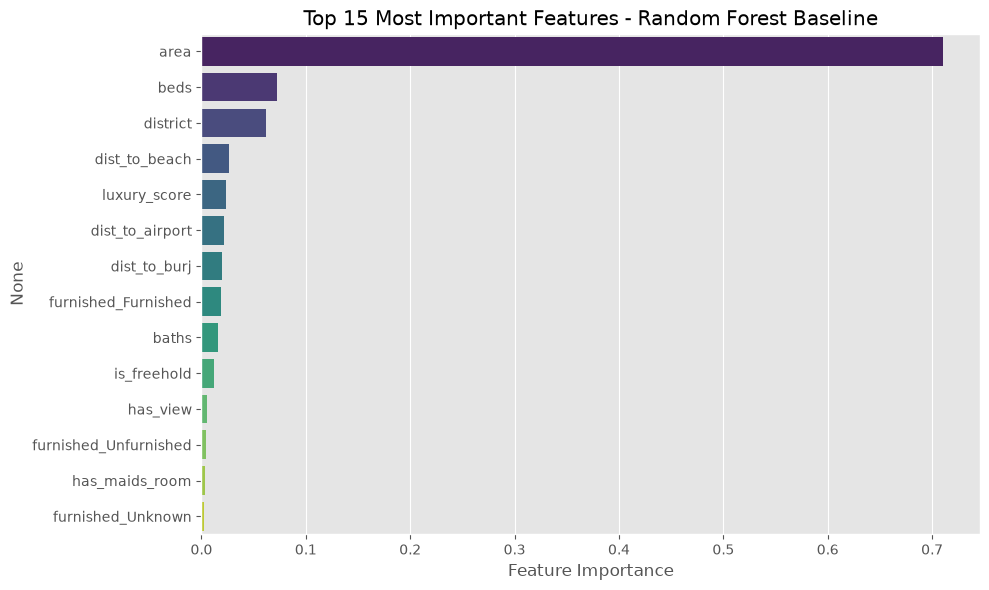

In [6]:
# Extract Feature Importances from Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', models['Random Forest'])])
rf_pipeline.fit(X_train, y_train)

# Get feature names
all_features = [f.split('__')[-1] for f in rf_pipeline.named_steps['preprocessor'].get_feature_names_out()]

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Most Important Features - Random Forest Baseline')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

### Key Findings
1. **Random Forest** performs significantly better than **Linear Regression** on the non-linear relationship between features and property prices.
2. **Area (sqft)** and **Bedroom count** are key drivers in property prices.
3. Specific **District tiers** command major premiums (e.g. Downtown Dubai and Palm Jumeirah).